# Average node values

This notebook computes average node values comparing SD, null, and random groupings across Boolean network models.

Results are cached to CSV to allow rapid iteration on figures.

Generates figures 8 and s6.

In [ ]:
import pandas as pd

import sdmarkov.plotting.config as pc
from sdmarkov.basins import get_average_node_values
from sdmarkov.matrix_operations import get_rms_diff
from sdmarkov.transition_matrix import get_uniform_matrix
from sdmarkov.analysis.model_context import iter_model_contexts
from sdmarkov.analysis.collect import generate_dataframe
from sdmarkov.analysis.postprocessing import network_level_metrics_df
from sdmarkov.plotting.figures import plot_violin_figure, plot_distribution_figure, save_figure

In [2]:
IMPORT_CSV = False
REBUILD_CONTEXTS = False
DEBUG = False

CACHE_DIR = "../.cache/model_contexts"
CSV_FILE = "../results/average_node_values.csv"

# Parameters for generating data
MODEL_DIRECTORY = "../models/random_nk3"
UPDATE = "asynchronous"
N_RANDOM = 30 # number of random models
DEBUG = False
NSQUARE_STEPS = 20 # number of steps for nsquare

# Figure configuration
FIGURE_DIR = "../results/figures"

MAIN_FIGURE_ID = "8"
SUP_FIGURE_ID = "s6"
METRICS = ["rmsd"]
METHODS = None # plot all methods

## Data generation or loading

In [3]:
# --- Experiment-specific analysis ---
def get_data_average_node_values(
    context,
    DEBUG=False,
):
    """
    Compute average node values for a single Boolean network model.

    Parameters
    ----------
    context : ModelContext
        Pre-built model context.
    DEBUG : bool, optional
        Enable verbose output in lower-level metric computations.

    Returns
    -------
    pd.DataFrame
        Long-format DataFrame with one row per method (and per random run).
        Returns an empty DataFrame if the model has fewer than two attractors.
    """

    rows = []

    # Unpack model context
    model_name = context.model_name
    update = context.update
    n_states = context.n_states
    n_attractors = context.n_attractors
    T_inf = context.T_inf
    Tsd_inf_expanded = context.Tsd_inf_expanded
    Tnull_inf_expanded = context.Tnull_inf_expanded
    n_random = context.random.n_random
    Trandom_inf_expanded_list = context.random.Trandom_inf_expanded

    # filter out networks with less than 2 attractors
    if n_attractors < 2:
        return pd.DataFrame(rows)

    # Actual
    avg_node_values = get_average_node_values(T_inf)

    # Reference
    Tref = get_uniform_matrix(n_states)
    ref_avg = get_average_node_values(Tref, DEBUG=DEBUG)

    # MC
    sd_avg = get_average_node_values(Tsd_inf_expanded, DEBUG=DEBUG)
    null_avg = get_average_node_values(Tnull_inf_expanded, DEBUG=DEBUG)

    # --- inner helper to add row ---
    def _add_row(method, predictions, run=None):
        rmsd_val = get_rms_diff(avg_node_values, predictions, partial=True, DEBUG=DEBUG)
        rows.append({
            "model": model_name,
            "method": method,
            "run": run,
            "rmsd": rmsd_val,
            "n_states": n_states,
            "n_attractors": n_attractors,
            "update_scheme": update
        })

    # Deterministic / reference methods
    _add_row("sd_mc", sd_avg)
    _add_row("null_mc", null_avg)
    _add_row("ref", ref_avg)

    # Random runs
    for i in range(n_random):
        Trandom_inf_expanded = Trandom_inf_expanded_list[i]
        random_avg = get_average_node_values(Trandom_inf_expanded, DEBUG=DEBUG)
        _add_row("random_mc", random_avg, run=i)

    return pd.DataFrame(rows)

In [4]:
if IMPORT_CSV:
    df = pd.read_csv(CSV_FILE)
    print(f"Loaded cached results from {CSV_FILE}.")
else:
    ctxs = iter_model_contexts(model_directory=MODEL_DIRECTORY,
                               update=UPDATE,
                               nsquare_steps=NSQUARE_STEPS,
                               n_random=N_RANDOM,
                               cache_dir=CACHE_DIR,
                               force_rebuild=REBUILD_CONTEXTS,
                               DEBUG=DEBUG,
                               )

    df = generate_dataframe(
        model_contexts=ctxs,
        data_function=get_data_average_node_values,
        schema={
            "n_states": int,
            "n_attractors": int,
            "run": "Int64",
        },
        DEBUG=DEBUG,
    )
    df.to_csv(CSV_FILE, index=False)
    print(f"Saved results to {CSV_FILE}.")

Preparing contexts for 100 models
[  1/100] n010_000.bnet
[  2/100] n010_001.bnet
[  3/100] n010_002.bnet
[  4/100] n010_003.bnet
[  5/100] n010_004.bnet
[  6/100] n010_005.bnet
[  7/100] n010_006.bnet
[  8/100] n010_007.bnet
[  9/100] n010_008.bnet
[ 10/100] n010_009.bnet
[ 11/100] n010_010.bnet
[ 12/100] n010_011.bnet
[ 13/100] n010_012.bnet
[ 14/100] n010_013.bnet
[ 15/100] n010_014.bnet
[ 16/100] n010_015.bnet
[ 17/100] n010_016.bnet
[ 18/100] n010_017.bnet
[ 19/100] n010_018.bnet
[ 20/100] n010_019.bnet
[ 21/100] n010_020.bnet
[ 22/100] n010_021.bnet
[ 23/100] n010_022.bnet
[ 24/100] n010_023.bnet
[ 25/100] n010_024.bnet
[ 26/100] n010_025.bnet
[ 27/100] n010_026.bnet
[ 28/100] n010_027.bnet
[ 29/100] n010_028.bnet
[ 30/100] n010_029.bnet
[ 31/100] n010_030.bnet
[ 32/100] n010_031.bnet
[ 33/100] n010_032.bnet
[ 34/100] n010_033.bnet
[ 35/100] n010_034.bnet
[ 36/100] n010_035.bnet
[ 37/100] n010_036.bnet
[ 38/100] n010_037.bnet
[ 39/100] n010_038.bnet
[ 40/100] n010_039.bnet
[ 41/1

In [5]:
print("Preview of results DataFrame:")
display(df.head())

print("\nDataFrame shape:", df.shape)
print("Methods present:", df.method.unique())
print("Number of unique networks:", df.model.unique())

Preview of results DataFrame:


,model,method,run,rmsd,n_states,n_attractors,update_scheme
0,n010_000.bnet,sd_mc,<NA>,0.117484,1024,2,asynchronous
1,n010_000.bnet,null_mc,<NA>,0.150764,1024,2,asynchronous
2,n010_000.bnet,ref,<NA>,0.350328,1024,2,asynchronous
3,n010_000.bnet,random_mc,0,0.150211,1024,2,asynchronous
4,n010_000.bnet,random_mc,1,0.151612,1024,2,asynchronous



DataFrame shape: (1518, 7)
Methods present: ['sd_mc' 'null_mc' 'ref' 'random_mc']
Number of unique networks: ['n010_000.bnet' 'n010_001.bnet' 'n010_004.bnet' 'n010_006.bnet'
 'n010_007.bnet' 'n010_008.bnet' 'n010_009.bnet' 'n010_011.bnet'
 'n010_013.bnet' 'n010_015.bnet' 'n010_016.bnet' 'n010_018.bnet'
 'n010_023.bnet' 'n010_024.bnet' 'n010_026.bnet' 'n010_029.bnet'
 'n010_032.bnet' 'n010_033.bnet' 'n010_034.bnet' 'n010_035.bnet'
 'n010_036.bnet' 'n010_040.bnet' 'n010_043.bnet' 'n010_048.bnet'
 'n010_049.bnet' 'n010_051.bnet' 'n010_052.bnet' 'n010_055.bnet'
 'n010_059.bnet' 'n010_060.bnet' 'n010_061.bnet' 'n010_063.bnet'
 'n010_069.bnet' 'n010_070.bnet' 'n010_071.bnet' 'n010_074.bnet'
 'n010_076.bnet' 'n010_077.bnet' 'n010_080.bnet' 'n010_083.bnet'
 'n010_085.bnet' 'n010_091.bnet' 'n010_094.bnet' 'n010_097.bnet'
 'n010_098.bnet' 'n010_099.bnet']


## Data analysis

In [6]:
# filter out networks with a single attractor
df_multi = df[df["n_attractors"] > 1].copy()

print("Dataframe filtered to networks with multiple attractors")
print("DataFrame shape:", df_multi.shape)
print("Methods present:", df_multi.method.unique())
print("Number of unique networks:", df_multi.model.nunique())

display(df_multi.head())

Dataframe filtered to networks with multiple attractors
DataFrame shape: (1518, 7)
Methods present: ['sd_mc' 'null_mc' 'ref' 'random_mc']
Number of unique networks: 46


,model,method,run,rmsd,n_states,n_attractors,update_scheme
0,n010_000.bnet,sd_mc,<NA>,0.117484,1024,2,asynchronous
1,n010_000.bnet,null_mc,<NA>,0.150764,1024,2,asynchronous
2,n010_000.bnet,ref,<NA>,0.350328,1024,2,asynchronous
3,n010_000.bnet,random_mc,0,0.150211,1024,2,asynchronous
4,n010_000.bnet,random_mc,1,0.151612,1024,2,asynchronous


In [7]:
df_metrics = network_level_metrics_df(df=df_multi)

print("Preview of network-level metrics DataFrame:")
display(df_metrics.head())

print("\nDataFrame shape:", df_metrics.shape)
print("Methods present:", df_metrics.method.unique())
print("Number of unique networks:", df_metrics.model.nunique())

print("\nNetwork-level classification metrics:")
metrics = ["rmsd"]
summary = (
    df_metrics
    .groupby("method")[metrics]
    .agg(["mean", "min", "median", "max"])
)

display(summary)

Preview of network-level metrics DataFrame:


,model,method,rmsd,n_states,n_attractors,update_scheme
0,n010_000.bnet,null_mc,0.150764,1024.0,2.0,asynchronous
1,n010_000.bnet,random_mc,0.150743,1024.0,2.0,asynchronous
2,n010_000.bnet,ref,0.350328,1024.0,2.0,asynchronous
3,n010_000.bnet,sd_mc,0.117484,1024.0,2.0,asynchronous
4,n010_001.bnet,null_mc,0.119433,64.0,5.0,asynchronous



DataFrame shape: (184, 6)
Methods present: ['null_mc' 'random_mc' 'ref' 'sd_mc']
Number of unique networks: 46

Network-level classification metrics:


rmsd                         
               mean  min    median       max
method                                      
null_mc    0.104749  0.0  0.093702  0.407622
random_mc  0.104771  0.0  0.089169  0.407516
ref        0.301876  0.0  0.341540  0.475903
sd_mc      0.048072  0.0  0.030116  0.251570

## Plotting

In [8]:
pc.apply_style()

INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


PosixPath('../results/figures/Figure_8_Average_node_values.png')

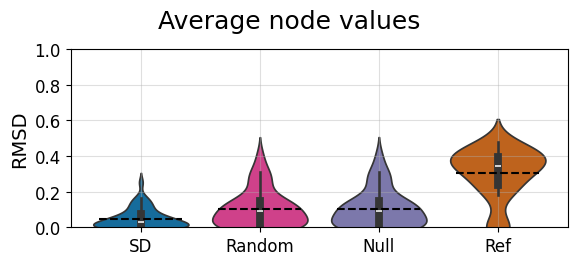

In [9]:
fig1 = plot_violin_figure(df_metrics, metrics=METRICS, figure_id=MAIN_FIGURE_ID, title_loc=0.89)

save_figure(fig1, figure_id=MAIN_FIGURE_ID, outdir=FIGURE_DIR)

PosixPath('../results/figures/Figure_s6_Average_node_values.png')

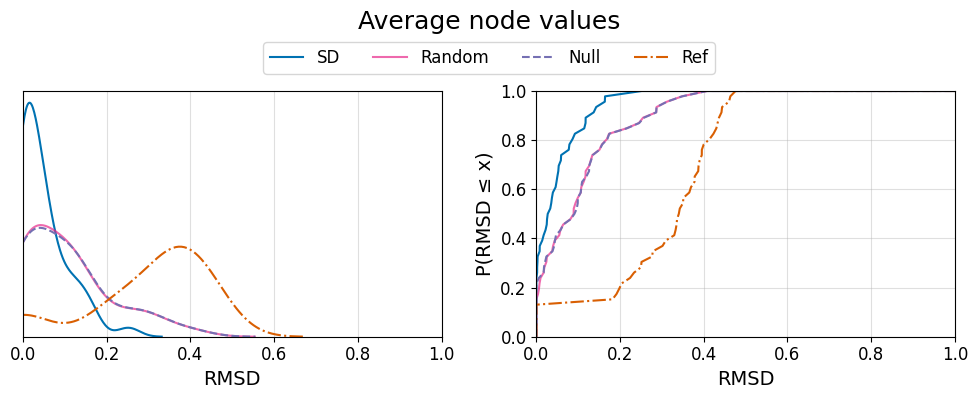

In [10]:
fig2 = plot_distribution_figure(df_metrics, metrics=METRICS, figure_id=SUP_FIGURE_ID, legend_loc=0.94)

save_figure(fig2, figure_id=SUP_FIGURE_ID, outdir=FIGURE_DIR)